## GAN

**GAN(Generative Adversarial Network)** 은 실제 데이터와 비슷한 샘플을 만드는 Generator와 실제·가짜를 구분하는 Discriminator를 번갈아 학습하는 생성 모델이다.

GAN에서 **실제 이미지**는 데이터셋에서 가져온 이미지이고, **가짜 이미지**는 Generator가 noise로부터 만든 이미지이다.



## GAN의 두 최적화 단계

![GAN 한 번의 학습 iteration](https://cdn.jsdelivr.net/gh/goat-skn-ai/image-repo@20132d4eb888d7c341e15c2fb4573d0ecf60c0da/09_multimodal/05_image_generation/02_gan_training_step.svg)

그림의 위쪽 경로에서는 MNIST 실제 이미지와 `Generator(noise)`가 만든 가짜 이미지를 사용해 Discriminator를 갱신한다. 아래쪽 경로에서는 가짜 이미지를 Discriminator가 실제로 판단하도록 Generator를 갱신한다. 이 두 단계를 모든 mini-batch에서 반복하면 Generator가 MNIST의 이미지 분포를 점차 학습한다.


## 필수 패키지 설치

In [1]:
%pip install -q torch torchvision matplotlib

Note: you may need to restart the kernel to use updated packages.


## MNIST 실제 이미지 준비

`torchvision.datasets.MNIST`는 28×28 크기의 흑백 손글씨 이미지와 숫자 label을 제공한다. GAN은 label을 사용하지 않고 이미지 분포만 학습하므로 DataLoader가 반환한 두 값 중 이미지만 학습에 사용한다.

`ToTensor()`가 이미지를 `(1, 28, 28)` Tensor로 바꾸고, `Normalize((0.5,), (0.5,))`가 픽셀 범위를 `[0, 1]`에서 `[-1, 1]`로 변환한다. 이 범위는 Generator의 마지막 `Tanh` 출력 범위와 일치한다. 처음 실행할 때는 MNIST 파일을 `./data`에 내려받으며, 이후에는 저장된 파일을 다시 사용한다.


학습 이미지 수: 6000
이미지 batch shape: (128, 1, 28, 28)
label 예시: [4, 4, 6, 1, 7, 9, 1, 2]


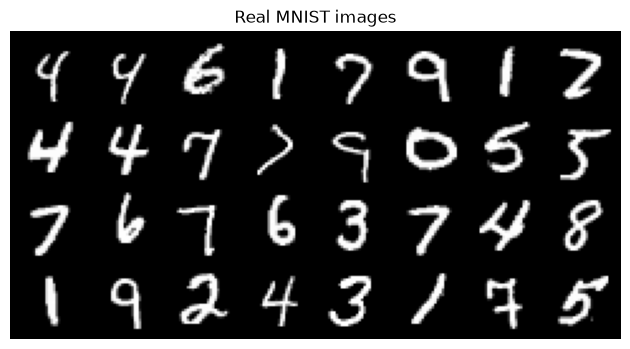

In [16]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

torch.manual_seed(42)
device = torch.device("cpu")

MAX_SAMPLES = 6_000
BATCH_SIZE = 128
EPOCHS = 50
SNAPSHOT_EPOCHS = {1, 5, 10, 15, 20, 25, EPOCHS}
NOISE_DIM = 64

# 이미지를 Tensor 형태로 변환하고 정규화까지 진행
image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

full_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=image_transform,
)
train_dataset = Subset(full_dataset, range(MAX_SAMPLES))
train_loader = DataLoader( # 지정된 배치 크기만큼 데이터를 가져오기
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

preview_real_images, preview_labels = next(iter(train_loader))
real_grid = make_grid(preview_real_images[:32], nrow=8, normalize=True, value_range=(-1, 1))

print("학습 이미지 수:", len(train_dataset))
print("이미지 batch shape:", tuple(preview_real_images.shape))
print("label 예시:", preview_labels[:8].tolist())
plt.figure(figsize=(8, 4))
plt.imshow(real_grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Real MNIST images")
plt.show()


## 이미지용 Generator와 Discriminator 준비

**Generator**는 길이 64의 noise 벡터를 784개 픽셀로 변환한 뒤 `Unflatten`으로 `(1, 28, 28)` 이미지 shape를 만든다. 마지막 `Tanh`는 생성 픽셀을 실제 이미지와 같은 `[-1, 1]` 범위로 제한한다.

**Discriminator**는 이미지를 `Flatten`해 784개 값을 가진 벡터로 바꾸고 실제·가짜 판단용 logit 하나를 출력한다. `BCEWithLogitsLoss`가 내부에서 sigmoid를 처리하므로 Discriminator 마지막에는 별도의 `Sigmoid`를 붙이지 않는다.


In [13]:
# 생성자
# - 길이 64의 무작위 noise를 계층을 통과시켜 (1, 28, 28) 이미지로 변환
generator = nn.Sequential( # Sequential() : 순서대로 진행
    nn.Linear(NOISE_DIM, 128), # NOISE_DIM : 64 -> 128 차원
    nn.LeakyReLU(negative_slope=0.2), # 음수 -> 기울기를 완화
    nn.Linear(128, 256),
    nn.LeakyReLU(negative_slope=0.2),
    nn.Linear(256, 28 * 28), # 28 * 28 = 748 (1차원)
    nn.Tanh(), # 하이퍼볼릭 탄젠트
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)) # 다차원의 형태로 이미지 복원
).to(device)

# 판별자
discriminator = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256), # 784 -> 256
    nn.LeakyReLU(negative_slope=0.2),
    nn.Dropout(p=0.2),
    nn.Linear(256, 128),
    nn.LeakyReLU(negative_slope=0.2),
    nn.Linear(128, 1), # 최종 output은 1개(logit)
    # -> sigmoid를 이용해서 진짜/가짜 판별
).to(device)

criterion = nn.BCEWithLogitsLoss()

learning_rate = 0.0002
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999)) # 판별자용
g_optimizer = torch.optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999)) # 생성자용

shape_test_noise = torch.randn(4, NOISE_DIM, device=device)
shape_test_images = generator(shape_test_noise)
shape_test_logits = discriminator(shape_test_images)

print("Generator:", tuple(shape_test_noise.shape), "->", tuple(shape_test_images.shape))
print("Discriminator:", tuple(shape_test_images.shape), "->", tuple(shape_test_logits.shape))


Generator: (4, 64) -> (4, 1, 28, 28)
Discriminator: (4, 1, 28, 28) -> (4, 1)


## GAN 반복 학습

각 mini-batch에서 먼저 Discriminator를 갱신한다. 실제 이미지에는 target `1`, `Generator(noise)`가 만든 가짜 이미지에는 target `0`을 사용하며, `detach()`로 Generator 방향의 gradient를 차단한다.

이어서 Generator를 갱신한다. 새로 생성한 이미지를 Discriminator가 실제라고 판단하도록 target `1`을 사용하며, 이때는 gradient가 Discriminator를 지나 Generator까지 전달된다. loss는 두 모델의 상대적인 경쟁 결과이므로 반드시 계속 감소해야 하는 일반 분류 loss처럼 해석하지 않고 생성 이미지의 변화와 함께 확인한다.


In [17]:
fixed_noise = torch.randn(32, NOISE_DIM, device=device)
generated_snapshots = [generator(fixed_noise).detach().cpu()]
generated_snapshot_titles = ["Before training"]

for epoch in range(EPOCHS):
    d_loss_sum = 0.0
    g_loss_sum = 0.0

    for real_images, _ in train_loader: # 진짜 이미지
        real_images = real_images.to(device)
        current_batch_size = real_images.shape[0]

        # 실제 이미지는 1, 가짜 이미지는 0으로 분류하도록 판별자(Discriminator)를 갱신하는 과정
        d_optimizer.zero_grad()

        # 생성자가 가짜 이미지를 하나 생성
        fake_images_for_d = generator(torch.randn(current_batch_size, NOISE_DIM, device=device))

        # 판별자가 가짜 이미지 판별
        real_logits = discriminator(real_images)

        # detach()는 가짜 이미지를 Generator 계산 그래프에서 분리한다. 따라서 이 단계에서는 Generator가 갱신되지 않는다.
        fake_logits_for_d = discriminator(fake_images_for_d.detach())

        # 판별 결과를 이용해서 손실(loss) 구하기
        d_real_loss = criterion(real_logits, torch.ones_like(real_logits))
        d_fake_loss = criterion(fake_logits_for_d, torch.zeros_like(fake_logits_for_d))
        d_loss = (d_real_loss + d_fake_loss) / 2

        # 최적화
        d_loss.backward()
        d_optimizer.step()

        # Discriminator 파라미터는 고정하지만 입력에서 Generator까지 이어지는 gradient 경로는 유지된다.
        discriminator.requires_grad_(False)

        g_optimizer.zero_grad()
        fake_images_for_g = generator(torch.randn(current_batch_size, NOISE_DIM, device=device))
        fake_logits_for_g = discriminator(fake_images_for_g)

        g_loss = criterion(fake_logits_for_g, torch.ones_like(fake_logits_for_g))
        g_loss.backward()
        g_optimizer.step()

        discriminator.requires_grad_(True)

        d_loss_sum += d_loss.item()
        g_loss_sum += g_loss.item()

    if epoch + 1 in SNAPSHOT_EPOCHS:
        generated_snapshots.append(generator(fixed_noise).detach().cpu())
        generated_snapshot_titles.append(f"Epoch {epoch + 1}")

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"D loss: {d_loss_sum / len(train_loader):.4f} | "
        f"G loss: {g_loss_sum / len(train_loader):.4f}"
    )

Epoch 1/50 | D loss: 0.2577 | G loss: 2.8805
Epoch 2/50 | D loss: 0.2899 | G loss: 2.8120
Epoch 3/50 | D loss: 0.2877 | G loss: 2.7307
Epoch 4/50 | D loss: 0.2782 | G loss: 2.7066
Epoch 5/50 | D loss: 0.2477 | G loss: 2.8098
Epoch 6/50 | D loss: 0.2387 | G loss: 2.8480
Epoch 7/50 | D loss: 0.2234 | G loss: 2.9380
Epoch 8/50 | D loss: 0.2259 | G loss: 3.1096
Epoch 9/50 | D loss: 0.2372 | G loss: 3.1259
Epoch 10/50 | D loss: 0.2623 | G loss: 3.2294
Epoch 11/50 | D loss: 0.2972 | G loss: 2.9307
Epoch 12/50 | D loss: 0.2549 | G loss: 3.1128
Epoch 13/50 | D loss: 0.2951 | G loss: 3.0162
Epoch 14/50 | D loss: 0.2766 | G loss: 2.7826
Epoch 15/50 | D loss: 0.2562 | G loss: 2.9933
Epoch 16/50 | D loss: 0.2198 | G loss: 3.0944
Epoch 17/50 | D loss: 0.2297 | G loss: 2.8897
Epoch 18/50 | D loss: 0.2532 | G loss: 3.0848
Epoch 19/50 | D loss: 0.2473 | G loss: 3.0532
Epoch 20/50 | D loss: 0.2649 | G loss: 3.0346
Epoch 21/50 | D loss: 0.2344 | G loss: 3.0113
Epoch 22/50 | D loss: 0.2762 | G loss: 2.97

## 학습 전과 epoch별 생성 이미지 비교

모든 행은 동일한 `fixed_noise`에서 생성되므로 행 사이의 차이는 noise가 아니라 학습된 Generator 파라미터의 변화에서 생긴다. 학습 전에는 무작위 무늬에 가깝고, 학습이 진행되면 MNIST의 흰색 획과 검은 배경 같은 공통 특징이 나타난다.

모든 숫자가 선명하게 완성되는 것을 목표로 하지 않는다. 마지막에는 실제 MNIST와 생성 이미지를 나란히 놓고 획의 형태와 샘플 다양성을 확인한다.


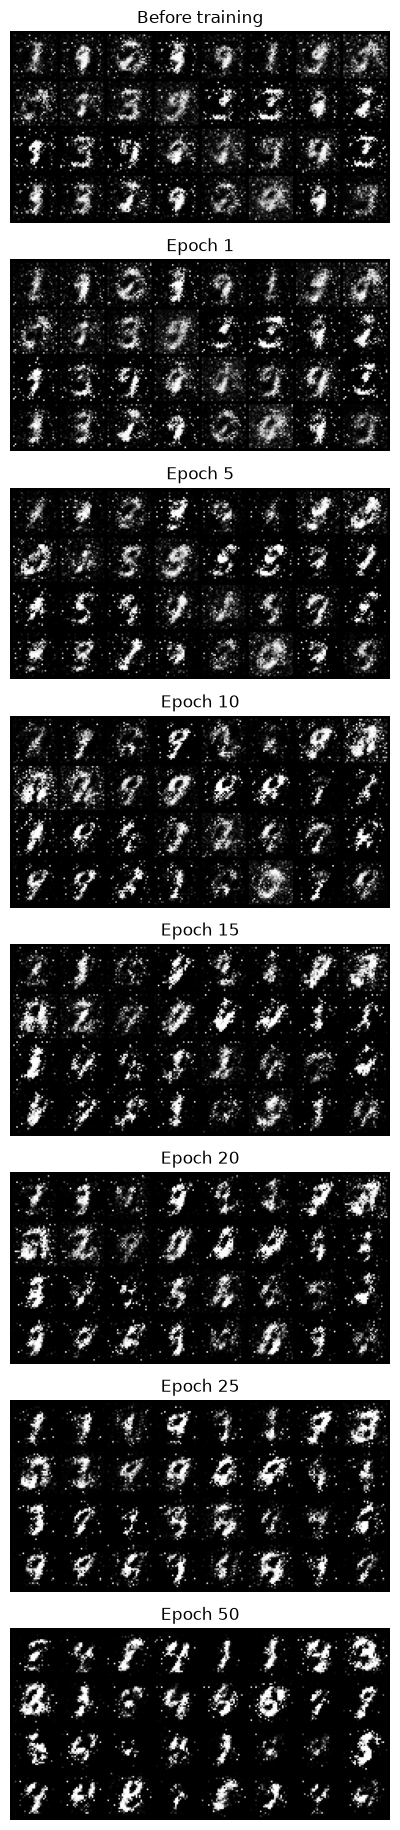

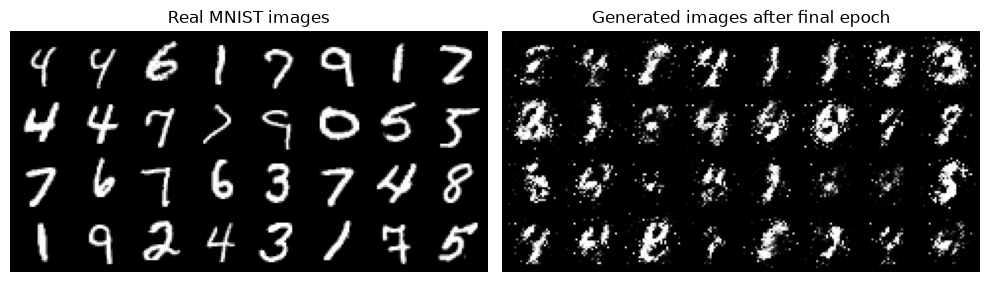

In [18]:
figure, axes = plt.subplots(len(generated_snapshots), 1, figsize=(8, 2.3 * len(generated_snapshots)))

for axis, images, title in zip(axes, generated_snapshots, generated_snapshot_titles):
    image_grid = make_grid(images, nrow=8, normalize=True, value_range=(-1, 1))
    axis.imshow(image_grid.permute(1, 2, 0))
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()

comparison_figure, comparison_axes = plt.subplots(1, 2, figsize=(10, 4))
comparison_items = [
    (preview_real_images[:32], "Real MNIST images"),
    (generated_snapshots[-1], "Generated images after final epoch"),
]

for axis, (images, title) in zip(comparison_axes, comparison_items):
    image_grid = make_grid(images, nrow=8, normalize=True, value_range=(-1, 1))
    axis.imshow(image_grid.permute(1, 2, 0))
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()


## Mode collapse의 경고 신호

**Mode collapse**는 서로 다른 noise를 넣어도 Generator가 거의 같은 이미지만 반복해서 만드는 현상이다. 아래에서는 서로 다른 noise로 만든 이미지와 첫 이미지를 강제로 반복한 비교 batch의 픽셀 표준편차를 계산한다.

표준편차가 0에 가까우면 이미지 반복을 의심할 수 있지만, 이 값은 **다양성의 간단한 경고 신호**일 뿐 숫자 모양이 자연스러운지를 나타내는 품질 점수는 아니다. 실제 grid에서 서로 다른 획과 모양이 나타나는지도 함께 확인한다.


In [19]:
with torch.no_grad():
    evaluation_noise = torch.randn(64, NOISE_DIM, device=device)
    generated_batch = generator(evaluation_noise).cpu()

collapsed_batch = generated_batch[:1].repeat(generated_batch.shape[0], 1, 1, 1)

generated_diversity = generated_batch.flatten(start_dim=1).std(dim=0, unbiased=False).mean()
collapsed_diversity = collapsed_batch.flatten(start_dim=1).std(dim=0, unbiased=False).mean()

print("생성 이미지 batch shape:", tuple(generated_batch.shape))
print("현재 Generator의 평균 픽셀 표준편차:", float(generated_diversity))
print("강제 collapse의 평균 픽셀 표준편차:", float(collapsed_diversity))


생성 이미지 batch shape: (64, 1, 28, 28)
현재 Generator의 평균 픽셀 표준편차: 0.28931519389152527
강제 collapse의 평균 픽셀 표준편차: 0.0


## 실제 사진 생성으로 확장하려면

![PyTorch 공식 DCGAN이 생성한 얼굴 이미지 모음](https://docs.pytorch.org/tutorials/_images/sphx_glr_dcgan_faces_tutorial_003.png)

현재 실습은 CPU 실행 속도를 위해 28×28 흑백 이미지와 완전연결 신경망을 사용한다. 얼굴처럼 더 큰 컬러 사진을 생성하려면 Generator에 `ConvTranspose2d`, Discriminator에 `Conv2d`를 사용하는 DCGAN 구조와 더 많은 학습 데이터·epoch가 필요하다.

출처: [PyTorch 공식 DCGAN 튜토리얼](https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html)
